In [1]:
%load_ext autoreload
%autoreload 3
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, os, re, math, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import permutation_test_score, KFold

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/shared_helper_modules')

from spk_feat_cluster_analysis import load_chunked_specparam_results, trim_edges
from config import (CELL_IDS, DICT_PATCH_FS, SPE1_DATA_ROOT, SPE1_PICKLE_ROOT, LFP_FS)

warnings.filterwarnings('ignore', message='use_inf_as_na option is deprecated',
                        category=FutureWarning, module='seaborn')
warnings.filterwarnings('ignore', message=r'invalid value encountered in log10',
                        category=RuntimeWarning, module=r'.*specparam.*')

In [2]:
# ── Cell configuration ────────────────────────────────────────────────────────
cell_num = 4

# Symmetric 50 ms windows immediately around the spike
PRE_WIN      = (-0.055, -0.005)  # pre-spike:  −55 → −5 ms
POST_WIN     = ( 0.005,  0.055)  # post-spike: +5 → +55 ms
BASELINE_WIN = (-0.20,  -0.10)   # baseline: −200 → −100 ms (within specparam coverage for all cells)

# Ridge regression settings
ALPHAS   = np.logspace(-3, 3, 100)
N_PERM   = 1000
RNG_SEED = 42

## 1. Load Pickles

In [3]:
# Cluster DataFrame  (spike waveform features + log ISI)
cluster_pickle = os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles', f'c{cell_num}_cluster_df.pkl')
with open(cluster_pickle, 'rb') as f:
    df_features_clust = pickle.load(f)
print(f'Loaded cluster_df: {len(df_features_clust)} spikes')
print(f'  columns: {list(df_features_clust.columns)}')

Loaded cluster_df: 1467 spikes
  columns: ['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp', 'peak_width', 'peak_sharpness', 'exp_lambda', 'exp_const', 'log_isi', 'spk_times_ms', 'spk_id', 'peak_amp_cluster', 'log_isi_cluster', 'spk_times_ms_cluster']


In [4]:
# Simple LFP pickles  (sliding-window lfp_mean, lfp_std, lfp_exponent)
simple_pickle = os.path.join(SPE1_PICKLE_ROOT, 'simple_lfp_pickles', f'c{cell_num}_simple_lfp.pkl')
with open(simple_pickle, 'rb') as f:
    lfp_windows_by_spike = pickle.load(f)
print(f'Loaded simple_lfp: {len(lfp_windows_by_spike)} spikes')
if lfp_windows_by_spike[0]:
    print(f'  keys: {list(lfp_windows_by_spike[0].keys())}')

Loaded simple_lfp: 1463 spikes
  keys: ['t_bins_s', 'lfp_mean', 'lfp_std', 'lfp_exponent']


In [5]:
# Specparam pickles  (sliding-window exponent, band AUCs, …)
chunk_dir    = os.path.join(SPE1_PICKLE_ROOT, 'multitaper_pickles', f'c{cell_num}')
chunk_prefix = f'c{cell_num}_specparam'

specparam_by_spike = load_chunked_specparam_results(save_dir=chunk_dir, prefix=chunk_prefix)
specparam_by_spike = trim_edges(specparam_by_spike, edge_sec=0.5)
print(f'Specparam ready for {len(specparam_by_spike)} spikes')

# Use the smaller count to align all three sources
n_spikes = len(specparam_by_spike)
df_reg   = df_features_clust.iloc[:n_spikes].reset_index(drop=True)
lfp_windows_by_spike = lfp_windows_by_spike[:n_spikes]
print(f'Aligned to {n_spikes} spikes')

Found 8 chunk files. Assembling master list...
Loading Chunks: 100%|██████████| 8/8 [00:01<00:00,  6.50it/s]
Success! Master list assembled with 1463 total spikes.
Specparam ready for 1463 spikes
Aligned to 1463 spikes


## 2. Build Feature and Target Matrices

**Predictors (X)** — three competing sets:
- *Waveform only*: 8 spike shape features
- *Log ISI only*: 1 feature
- *Waveform + Log ISI*: 9 features combined

**Targets (Y)** — 15 LFP scalars (5 features × 3 groups):

| Group | Formula | Scientific question |
|-------|---------|-------------------|
| Pre absolute | mean(pre window) | Do certain waveform shapes fire during particular LFP states? |
| Pre baseline-corrected | mean(pre) − mean(baseline) | Is LFP ramping in the ~750 ms before the spike? |
| Δ post − pre | mean(post) − mean(pre) | Spike-triggered change (ERP-equivalent) |

Baseline window: −0.75 → −0.5 s (fallback: earliest available data up to −0.05 s).

In [6]:
def win_avg(t_bins, arr, window):
    """Mean of a 1-D array over a time window (seconds)."""
    if t_bins is None or arr is None:
        return np.nan
    t = np.asarray(t_bins, float)
    a = np.asarray(arr, float)
    mask = (t >= window[0]) & (t <= window[1])
    if not np.any(mask):
        return np.nan
    vals = a[mask]
    return float(np.nanmean(vals)) if np.any(np.isfinite(vals)) else np.nan


# ── Predictor columns ─────────────────────────────────────────────────────────
waveform_cols   = ['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp',
                   'peak_width', 'peak_sharpness', 'exp_lambda', 'exp_const']
waveform_labels = ['Ramp Amp', 'Infl. Time', 'Infl. Amp', 'Peak Amp',
                   'Peak Width', 'Sharpness', 'Decay λ', 'Decay Const']

X_waveform = df_reg[waveform_cols].values
X_log_isi  = df_reg[['log_isi']].values
X_both     = np.hstack([X_waveform, X_log_isi])

predictor_sets = {
    'Waveform only':       (X_waveform, waveform_labels),
    'Log ISI only':        (X_log_isi,  ['Log ISI']),
    'Waveform + Log ISI':  (X_both,     waveform_labels + ['Log ISI']),
}

# ── Target columns ────────────────────────────────────────────────────────────
# 15 targets: 5 pre (absolute) + 5 pre−BL (pre minus baseline) + 5 delta (post−pre)
# All windows are within specparam coverage (−0.23 s) for all cells:
#   BASELINE_WIN = −200 → −100 ms
#   PRE_WIN      = −55  → −5 ms
#   POST_WIN     = +5   → +55 ms

feat_keys   = ['lfp_amp', 'lfp_std', 'gamma_auc', 'exponent', 'theta_auc']
feat_labels = ['LFP Amp', 'LFP Std', 'Gamma AUC', 'Exponent', 'Theta AUC']

target_names = (
    [f'pre_{k}'   for k in feat_keys] +
    [f'prebc_{k}' for k in feat_keys] +
    [f'delta_{k}' for k in feat_keys]
)
target_labels = (
    [f'Pre {l}'     for l in feat_labels] +
    [f'Pre−BL {l}'  for l in feat_labels] +
    [f'Δ {l}'       for l in feat_labels]
)

Y = np.full((n_spikes, 15), np.nan)

for i in range(n_spikes):
    sp        = specparam_by_spike[i]
    sw        = lfp_windows_by_spike[i]
    t_sp      = sp.get('t_bins_s')      if sp else None
    t_sw      = sw['t_bins_s']          if sw is not None else None
    band_aucs = sp.get('band_aucs', {}) if sp else {}

    def _sp(key):  return sp.get(key) if sp else None
    def _ba(band): return band_aucs.get(band)

    pre_vals = [
        win_avg(t_sw, sw['lfp_mean'] if sw else None, PRE_WIN),
        win_avg(t_sw, sw['lfp_std']  if sw else None, PRE_WIN),
        win_avg(t_sp, _ba('gamma'),                   PRE_WIN),
        win_avg(t_sp, _sp('exponent'),                PRE_WIN),
        win_avg(t_sp, _ba('theta'),                   PRE_WIN),
    ]
    bl_vals = [
        win_avg(t_sw, sw['lfp_mean'] if sw else None, BASELINE_WIN),
        win_avg(t_sw, sw['lfp_std']  if sw else None, BASELINE_WIN),
        win_avg(t_sp, _ba('gamma'),                   BASELINE_WIN),
        win_avg(t_sp, _sp('exponent'),                BASELINE_WIN),
        win_avg(t_sp, _ba('theta'),                   BASELINE_WIN),
    ]
    post_vals = [
        win_avg(t_sw, sw['lfp_mean'] if sw else None, POST_WIN),
        win_avg(t_sw, sw['lfp_std']  if sw else None, POST_WIN),
        win_avg(t_sp, _ba('gamma'),                   POST_WIN),
        win_avg(t_sp, _sp('exponent'),                POST_WIN),
        win_avg(t_sp, _ba('theta'),                   POST_WIN),
    ]

    Y[i,  0: 5] = pre_vals
    Y[i,  5:10] = [p - b if np.isfinite(p) and np.isfinite(b) else np.nan
                   for p, b in zip(pre_vals, bl_vals)]
    Y[i, 10:15] = [po - pr if np.isfinite(po) and np.isfinite(pr) else np.nan
                   for po, pr in zip(post_vals, pre_vals)]

nan_pct = np.isnan(Y).mean(axis=0) * 100
print('Target NaN %:')
for tl, pct in zip(target_labels, nan_pct):
    print(f'  {tl:22s}  {pct:.1f}%')

Target NaN %:
  Pre LFP Amp             0.0%
  Pre LFP Std             0.0%
  Pre Gamma AUC           0.0%
  Pre Exponent            0.0%
  Pre Theta AUC           0.0%
  Pre−BL LFP Amp          0.0%
  Pre−BL LFP Std          0.0%
  Pre−BL Gamma AUC        0.0%
  Pre−BL Exponent         0.0%
  Pre−BL Theta AUC        0.0%
  Δ LFP Amp               0.0%
  Δ LFP Std               0.0%
  Δ Gamma AUC             0.0%
  Δ Exponent              0.0%
  Δ Theta AUC             0.0%


## 3. Ridge Regression — 5-Fold Cross-Validated R² with Permutation Test

For each of the 10 LFP targets and each of the 3 predictor sets:
1. **Alpha tuning**: `RidgeCV` on the full data finds the best regularization strength once
2. **5-fold CV R²**: refit `Ridge(best_alpha)` with cross-validation — can be negative if model is uninformative
3. **Permutation test**: shuffle y `N_PERM` times, run same 5-fold CV → honest null distribution
4. **Beta weights**: full-data fit for visualization only

In [7]:
from sklearn.linear_model import Ridge

results = {tname: {} for tname in target_names}

# Shuffled KFold so temporal drift in the recording doesn't split train/test
# into different recording epochs (which would give catastrophically negative R²)
cv_splitter = KFold(n_splits=5, shuffle=True, random_state=RNG_SEED)

n_total = len(target_names) * len(predictor_sets)
pbar = tqdm(total=n_total, desc=f'c{cell_num} ridge CV', unit='model')

for t_idx, (tname, tlabel) in enumerate(zip(target_names, target_labels)):
    y_raw = Y[:, t_idx]

    for p_idx, (pname, (X_raw_p, plabels)) in enumerate(predictor_sets.items()):
        pbar.set_postfix(target=tlabel[:12], pred=pname[:10])
        valid = np.isfinite(X_raw_p).all(axis=1) & np.isfinite(y_raw)
        n_valid = int(valid.sum())

        if n_valid < 20:
            results[tname][pname] = dict(r2_cv=np.nan, p_val=np.nan,
                                         null_mean=np.nan, null_std=np.nan,
                                         best_alpha=np.nan, beta=None, n_valid=n_valid)
            pbar.update(1)
            continue

        X, y = X_raw_p[valid], y_raw[valid]

        X_z = StandardScaler().fit_transform(X)
        y_z = StandardScaler().fit_transform(y.reshape(-1, 1)).ravel()

        # Step 1: tune alpha once on full data
        alpha_cv = RidgeCV(alphas=ALPHAS, fit_intercept=True)
        alpha_cv.fit(X_z, y_z)
        best_alpha = float(alpha_cv.alpha_)

        # Step 2: permutation test with shuffled CV and fixed alpha
        pipe = make_pipeline(StandardScaler(), Ridge(alpha=best_alpha, fit_intercept=True))
        cv_score, perm_scores, p_val = permutation_test_score(
            pipe, X_z, y_z,
            cv=cv_splitter,
            n_permutations=N_PERM,
            scoring='r2',
            random_state=RNG_SEED * 100 + t_idx * 10 + p_idx,
            n_jobs=1,
        )

        # Step 3: full-data beta weights for visualization
        ridge_full = Ridge(alpha=best_alpha, fit_intercept=True)
        ridge_full.fit(X_z, y_z)

        results[tname][pname] = dict(
            r2_cv=float(cv_score),
            p_val=float(p_val),
            null_mean=float(np.mean(perm_scores)),
            null_std=float(np.std(perm_scores)),
            best_alpha=best_alpha,
            beta=dict(zip(plabels, ridge_full.coef_)),
            n_valid=n_valid,
            # FDR fields populated in next cell
            p_val_fdr=np.nan,
            sig_fdr=False,
        )
        pbar.update(1)

pbar.close()
print('Regression complete. Run next cell for FDR correction.')

c4 ridge CV: 100%|██████████| 45/45 [07:13<00:00,  9.62s/model, pred=Waveform +, target=Δ Theta AUC] 

Regression complete. Run next cell for FDR correction.


## 4. Summary Visualization

In [8]:
from statsmodels.stats.multitest import fdrcorrection

# Collect all 30 raw p-values (10 targets × 3 predictor sets)
test_keys = [(tname, pname)
             for tname in target_names
             for pname in predictor_sets.keys()]

raw_pvals = np.array([results[tname][pname].get('p_val', np.nan)
                      for tname, pname in test_keys])

pvals_for_fdr = np.where(np.isfinite(raw_pvals), raw_pvals, 1.0)
rejected, pvals_fdr = fdrcorrection(pvals_for_fdr, alpha=0.05, method='indep')

for (tname, pname), p_fdr, rej in zip(test_keys, pvals_fdr, rejected):
    results[tname][pname]['p_val_fdr'] = float(p_fdr)
    results[tname][pname]['sig_fdr']   = bool(rej)

n_sig_raw = int(np.sum(raw_pvals < 0.05))
n_sig_fdr = int(np.sum(rejected))
print(f'c{cell_num} — FDR correction (Benjamini-Hochberg, q=0.05)')
print(f'  Significant before FDR: {n_sig_raw} / {len(test_keys)}')
print(f'  Significant after  FDR: {n_sig_fdr} / {len(test_keys)}\n')

# ── Summary table with FDR-corrected significance ─────────────────────────────
print(f'c{cell_num} Ridge Regression — 5-fold CV R²  (N_PERM={N_PERM}, FDR q=0.05)\n')
col_w = 26
header = f'{"Target":<22}' + ''.join(f'{n:>{col_w}}' for n in predictor_sets.keys())
print(header)
print('-' * len(header))

for tname, tlabel in zip(target_names, target_labels):
    def fmt_cell(pname):
        res = results[tname].get(pname, {})
        r   = res.get('r2_cv',     np.nan)
        p   = res.get('p_val',     np.nan)
        pfdr= res.get('p_val_fdr', np.nan)
        ba  = res.get('best_alpha',np.nan)
        if not np.isfinite(r):
            return 'NaN'
        star = '*' if res.get('sig_fdr', False) else (' ' if (np.isfinite(p) and p < 0.05) else ' ')
        marker = '*' if res.get('sig_fdr') else ('~' if (np.isfinite(p) and p < 0.05) else ' ')
        return f'{r:+.4f}{marker} α={ba:.2g}'
    row = f'{tlabel:<22}' + ''.join(f'{fmt_cell(pn):>{col_w}}' for pn in predictor_sets.keys())
    print(row)

print('\n* FDR-corrected significant  ~ raw p<0.05 only  α = selected Ridge alpha')

c4 — FDR correction (Benjamini-Hochberg, q=0.05)
  Significant before FDR: 14 / 45
  Significant after  FDR: 12 / 45

c4 Ridge Regression — 5-fold CV R²  (N_PERM=1000, FDR q=0.05)

Target                             Waveform only              Log ISI only        Waveform + Log ISI
----------------------------------------------------------------------------------------------------
Pre LFP Amp                        +0.2601* α=27          -0.0079  α=1e+03             +0.2686* α=31
Pre LFP Std                        +0.1867* α=93          -0.0040  α=1e+03             +0.1856* α=93
Pre Gamma AUC                 +0.0056* α=7.6e+02          -0.0031  α=1e+03        +0.0051* α=8.7e+02
Pre Exponent                  +0.0511* α=3.3e+02          -0.0019  α=1e+03        +0.0531* α=3.3e+02
Pre Theta AUC                 -0.0006  α=6.6e+02          -0.0026  α=1e+03          -0.0006  α=1e+03
Pre−BL LFP Amp                  -0.0110  α=1e+03          -0.0085  α=1e+03          -0.0114  α=1e+03
Pre−BL LFP 

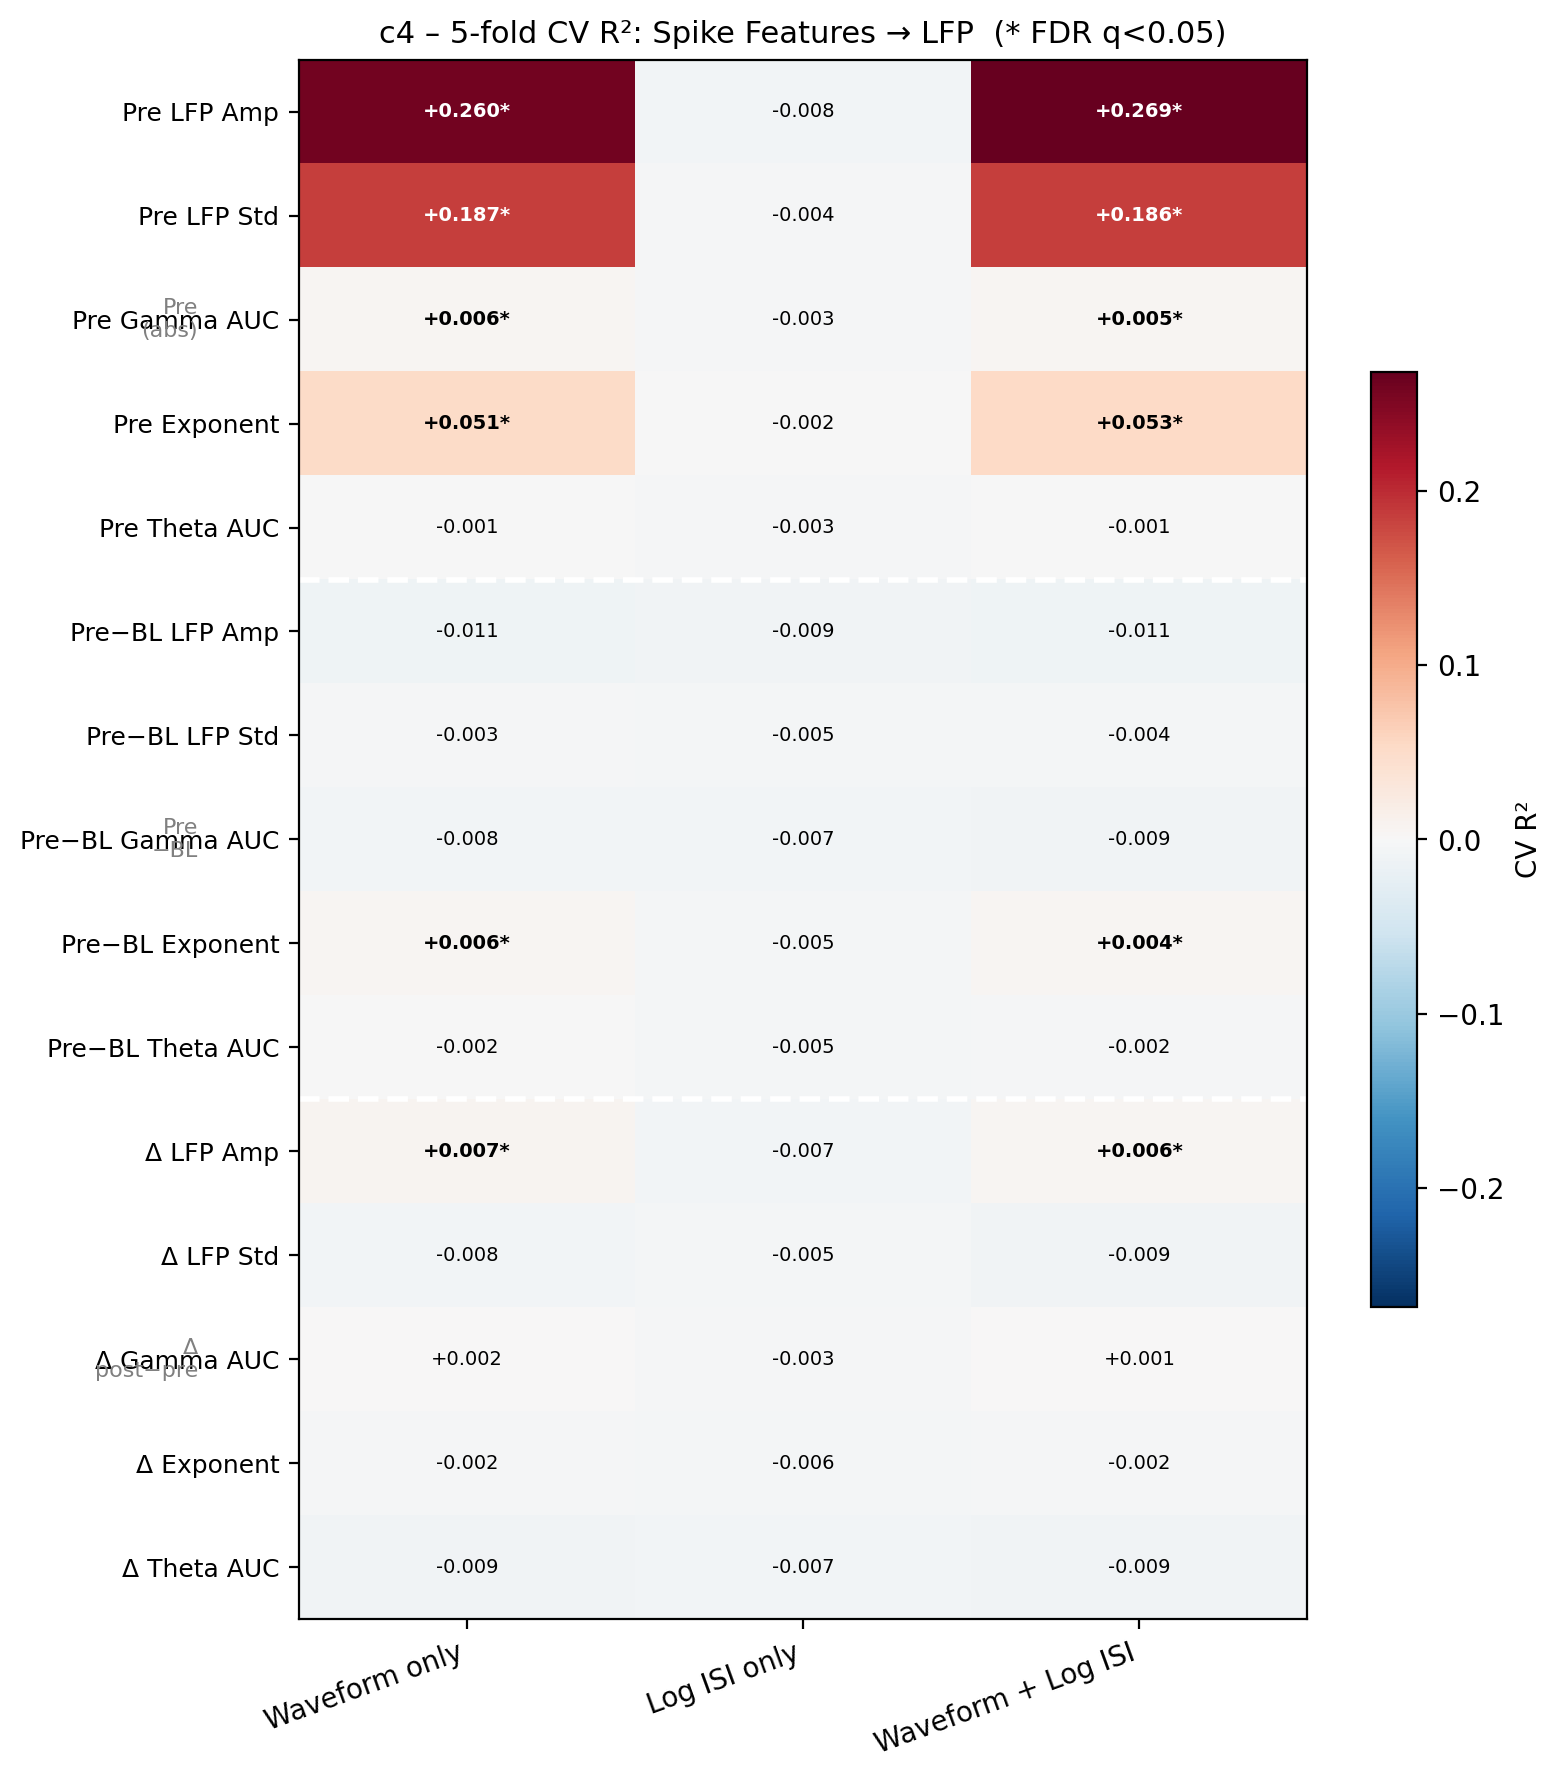

In [9]:
# ── R² heatmap: 15 targets × 3 predictor sets ────────────────────────────────
pred_names = list(predictor_sets.keys())
n_t = len(target_names)   # 15
n_p = len(pred_names)     # 3

r2_mat  = np.full((n_t, n_p), np.nan)
sig_mat = np.zeros((n_t, n_p), dtype=bool)

for t_idx, tname in enumerate(target_names):
    for p_idx, pname in enumerate(pred_names):
        res = results[tname].get(pname, {})
        r2_mat[t_idx, p_idx]  = res.get('r2_cv', np.nan)
        sig_mat[t_idx, p_idx] = res.get('sig_fdr', False)

vmax = max(abs(np.nanmax(r2_mat)), abs(np.nanmin(r2_mat)), 0.01)
vmin = -vmax

fig, ax = plt.subplots(figsize=(8, 9))
im = ax.imshow(r2_mat, aspect='auto', vmin=vmin, vmax=vmax, cmap='RdBu_r')

ax.set_xticks(range(n_p))
ax.set_xticklabels(pred_names, rotation=20, ha='right', fontsize=10)
ax.set_yticks(range(n_t))
ax.set_yticklabels(target_labels, fontsize=9)

for r in range(n_t):
    for c in range(n_p):
        v = r2_mat[r, c]
        if np.isfinite(v):
            star = '*' if sig_mat[r, c] else ''
            txt_col = 'white' if abs(v) > vmax * 0.6 else 'black'
            ax.text(c, r, f'{v:+.3f}{star}', ha='center', va='center',
                    fontsize=7, color=txt_col, fontweight='bold' if star else 'normal')

for divider in [4.5, 9.5]:
    ax.axhline(divider, color='white', lw=2, linestyle='--')

ax.text(-0.8,  2.0, 'Pre\n(abs)',  va='center', ha='right', fontsize=8, color='gray')
ax.text(-0.8,  7.0, 'Pre\n−BL',   va='center', ha='right', fontsize=8, color='gray')
ax.text(-0.8, 12.0, 'Δ\npost−pre',va='center', ha='right', fontsize=8, color='gray')

plt.colorbar(im, ax=ax, label='CV R²', shrink=0.6)
ax.set_title(f'c{cell_num} – 5-fold CV R²: Spike Features → LFP  (* FDR q<0.05)', fontsize=11)
fig.tight_layout()
plt.show()

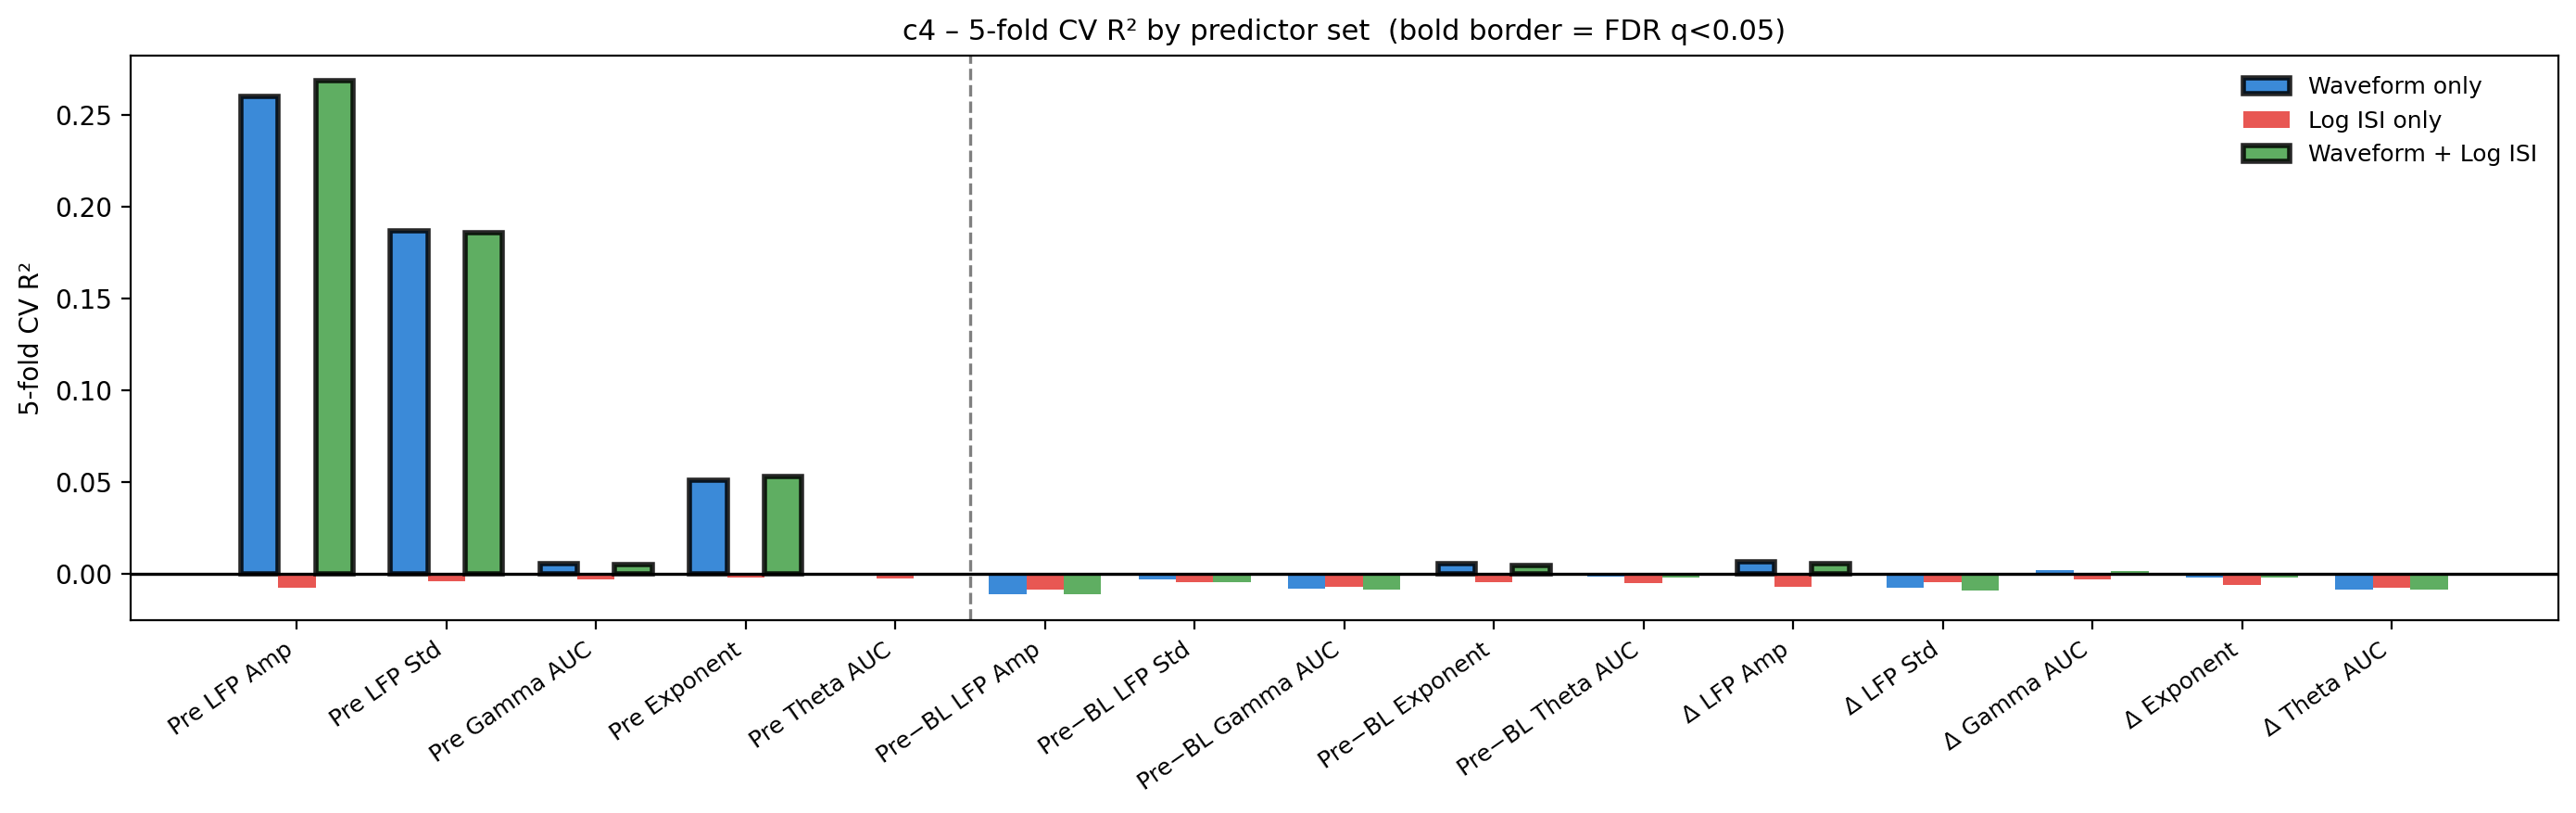

In [10]:
# ── Bar chart: CV R² per target, grouped by predictor set ─────────────────────
x   = np.arange(n_t)
bw  = 0.25
bar_colors = ['#1976D2', '#E53935', '#43A047']

fig, ax = plt.subplots(figsize=(14, 4.5))
for p_idx, (pname, col) in enumerate(zip(pred_names, bar_colors)):
    vals = r2_mat[:, p_idx]
    bars = ax.bar(x + (p_idx - 1) * bw, vals, width=bw, label=pname,
                  color=col, alpha=0.85)
    for b_i, bar in enumerate(bars):
        if sig_mat[b_i, p_idx]:
            bar.set_edgecolor('black')
            bar.set_linewidth(2.0)

ax.set_xticks(x)
ax.set_xticklabels(target_labels, rotation=35, ha='right', fontsize=9)
ax.axhline(0, color='k', lw=1.2)
ax.axvline(4.5, color='gray', lw=1.2, linestyle='--')
ax.set_ylabel('5-fold CV R²')
ax.legend(frameon=False, fontsize=9)
ax.set_title(f'c{cell_num} – 5-fold CV R² by predictor set  (bold border = FDR q<0.05)', fontsize=11)
fig.tight_layout()
plt.show()

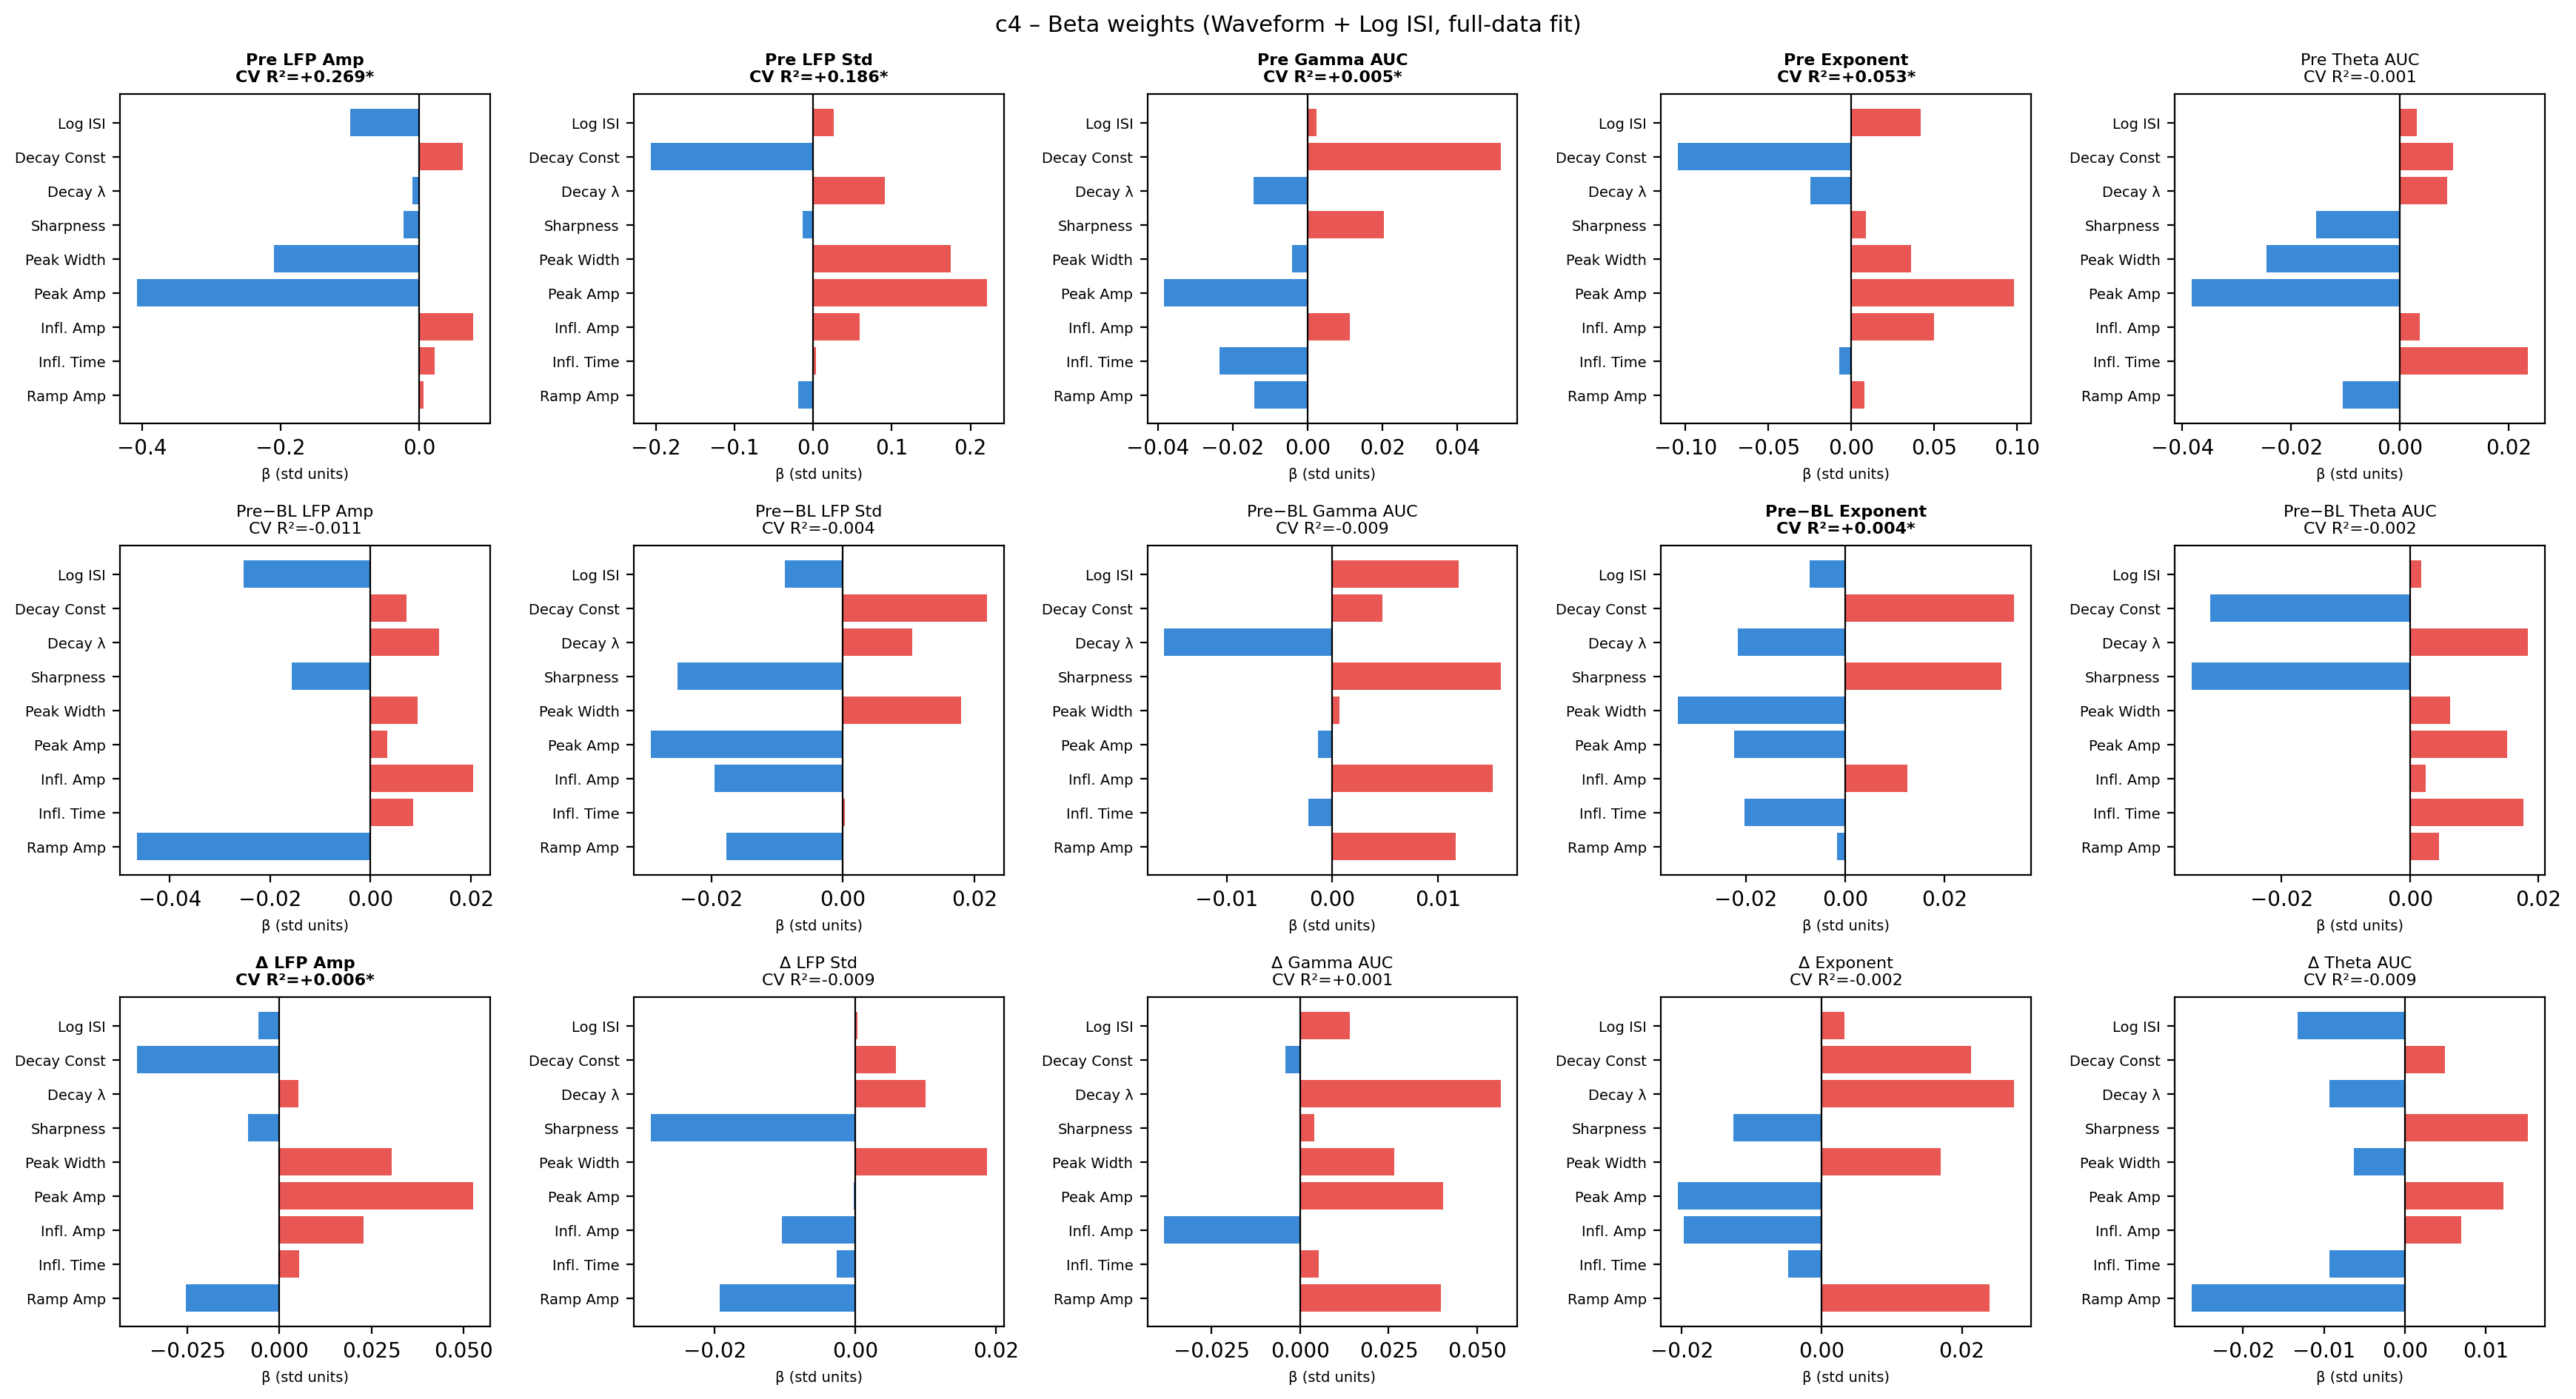

In [11]:
# ── Beta weights for 'Waveform + Log ISI' model, one subplot per target ────────
pname_both  = 'Waveform + Log ISI'
both_labels = waveform_labels + ['Log ISI']
n_beta      = len(both_labels)

ncols = 5
nrows = math.ceil(n_t / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.2), sharey=False)
axes = axes.flatten()
fig.suptitle(f'c{cell_num} – Beta weights (Waveform + Log ISI, full-data fit)', fontsize=11)

for t_idx, (tname, tlabel) in enumerate(zip(target_names, target_labels)):
    ax  = axes[t_idx]
    res = results[tname].get(pname_both, {})
    beta = res.get('beta')
    r2   = res.get('r2_cv',  np.nan)
    sig  = res.get('sig_fdr', False)

    if beta is None:
        ax.set_title(tlabel, fontsize=9)
        ax.text(0.5, 0.5, 'insufficient data', ha='center', va='center',
                transform=ax.transAxes, fontsize=8, color='gray')
        ax.axis('off')
        continue

    vals     = [beta.get(lbl, np.nan) for lbl in both_labels]
    colors_b = ['#E53935' if v > 0 else '#1976D2' for v in vals]
    y_pos    = np.arange(n_beta)

    ax.barh(y_pos, vals, color=colors_b, alpha=0.85)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(both_labels, fontsize=7)
    ax.axvline(0, color='k', lw=0.8)
    star = '*' if sig else ''
    ax.set_title(f'{tlabel}\nCV R²={r2:+.3f}{star}', fontsize=8,
                 fontweight='bold' if sig else 'normal')
    ax.set_xlabel('β (std units)', fontsize=7)

for i in range(n_t, len(axes)):
    axes[i].set_visible(False)

fig.tight_layout()
plt.show()

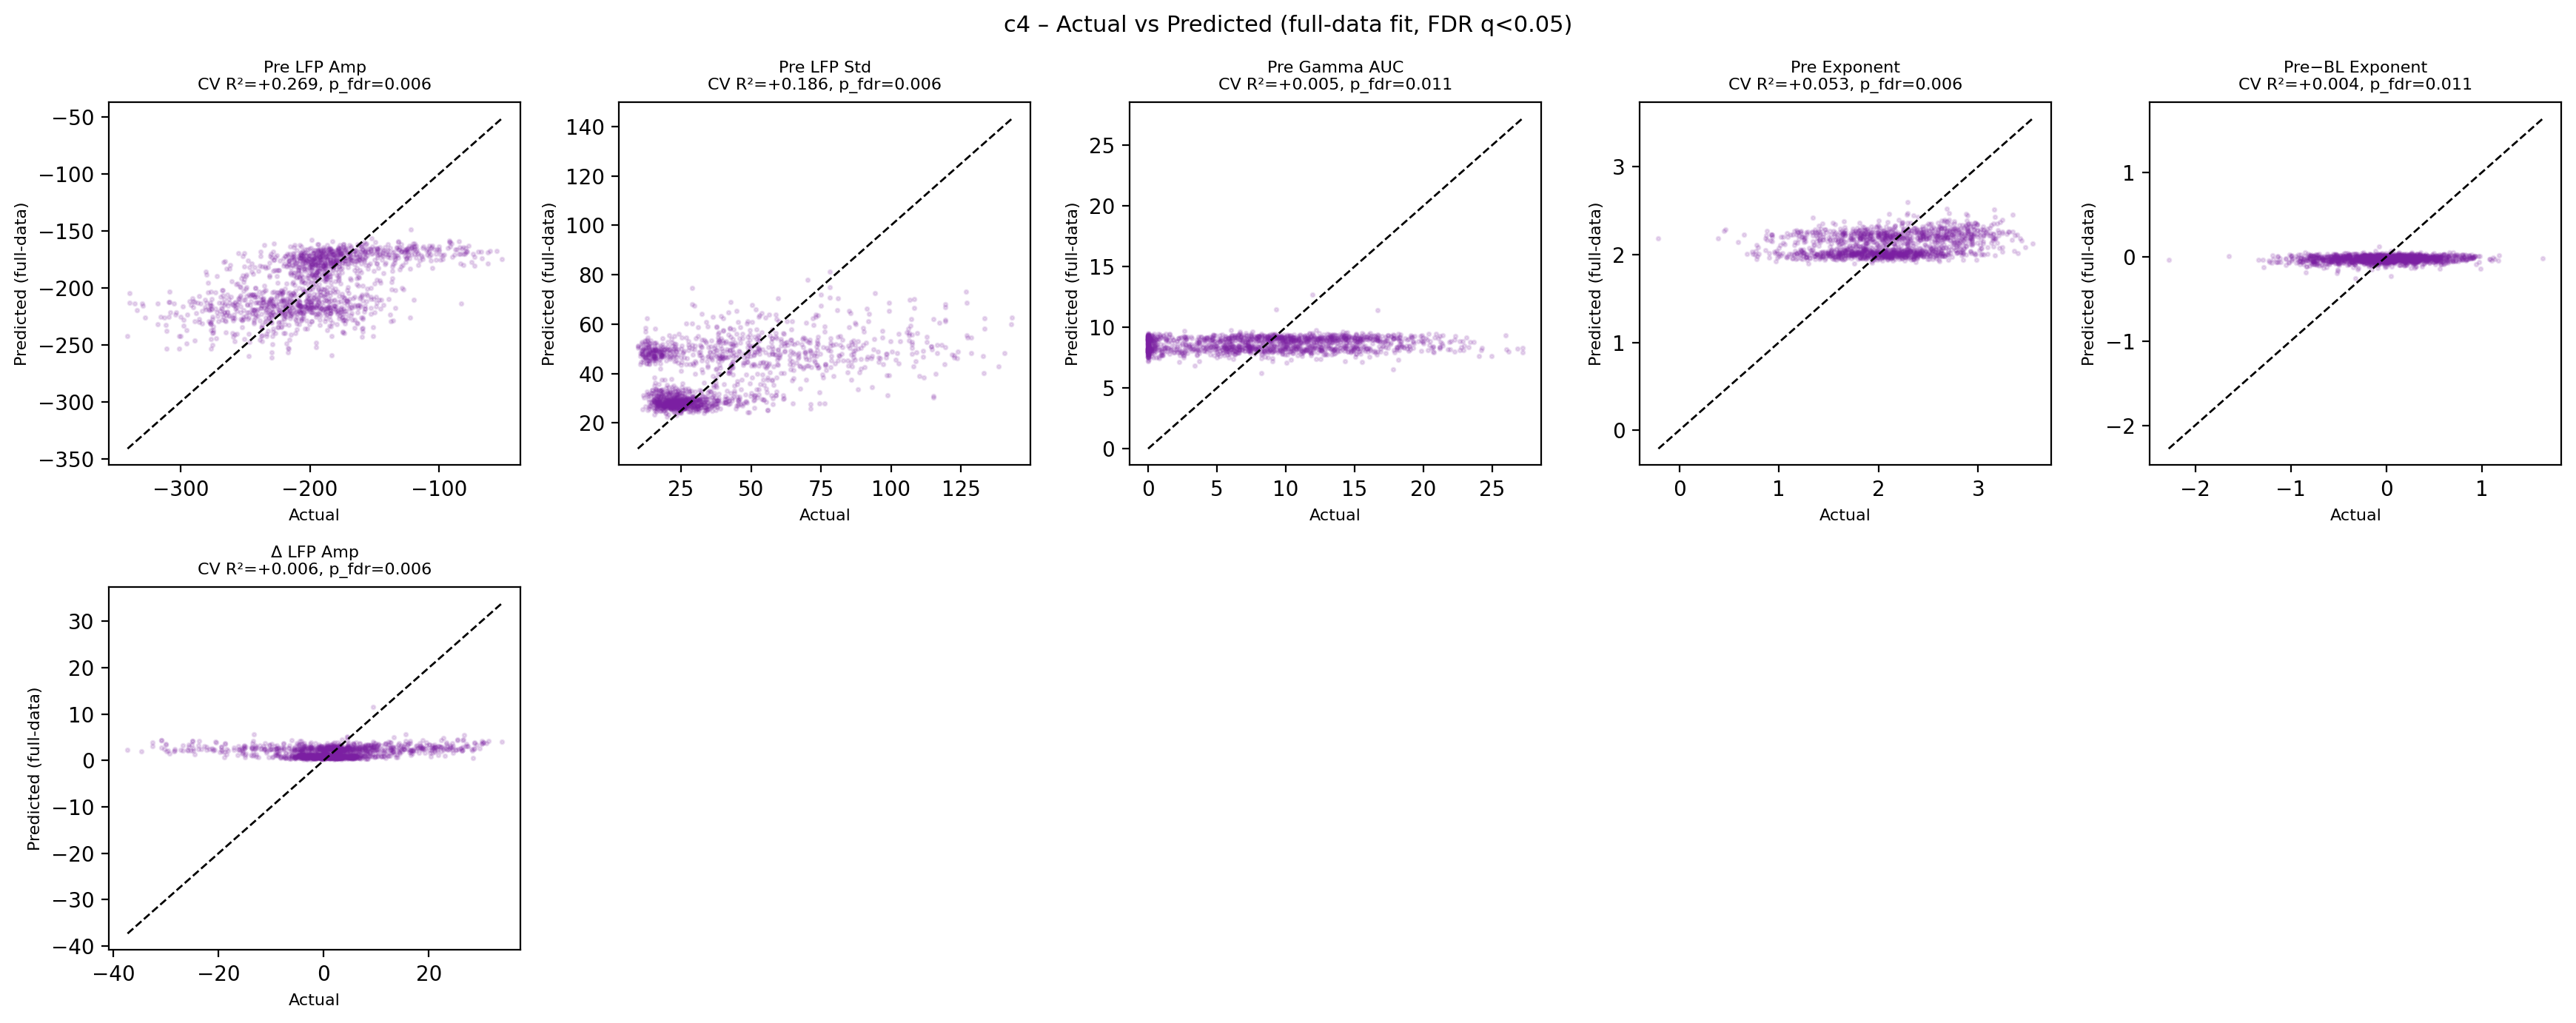

In [12]:
# ── Scatter plots for FDR-significant targets (Waveform + Log ISI) ────────────
sig_targets = [
    (t_idx, tname, tlabel)
    for t_idx, (tname, tlabel) in enumerate(zip(target_names, target_labels))
    if results[tname].get(pname_both, {}).get('sig_fdr', False)
]

if not sig_targets:
    print('No FDR-significant targets for the Waveform + Log ISI model.')
else:
    ncols = min(len(sig_targets), 5)
    nrows = math.ceil(len(sig_targets) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5))
    axes = np.array(axes).flatten() if len(sig_targets) > 1 else [axes]
    fig.suptitle(f'c{cell_num} – Actual vs Predicted (full-data fit, FDR q<0.05)', fontsize=11)

    for ax, (t_idx, tname, tlabel) in zip(axes, sig_targets):
        res   = results[tname][pname_both]
        alpha = res.get('best_alpha', 1.0)
        y_raw = Y[:, t_idx]
        valid = np.isfinite(X_both).all(axis=1) & np.isfinite(y_raw)
        X, y  = X_both[valid], y_raw[valid]

        X_z      = StandardScaler().fit_transform(X)
        scaler_y = StandardScaler()
        y_z      = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()
        ridge_plot = Ridge(alpha=alpha, fit_intercept=True)
        ridge_plot.fit(X_z, y_z)
        y_pred = scaler_y.inverse_transform(ridge_plot.predict(X_z).reshape(-1, 1)).ravel()

        ax.scatter(y, y_pred, alpha=0.15, s=3, rasterized=True, color='#7B1FA2')
        lo, hi = min(y.min(), y_pred.min()), max(y.max(), y_pred.max())
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
        ax.set_xlabel('Actual', fontsize=8)
        ax.set_ylabel('Predicted (full-data)', fontsize=8)
        r2  = res.get('r2_cv',     np.nan)
        pfdr= res.get('p_val_fdr', np.nan)
        ax.set_title(f'{tlabel}\nCV R²={r2:+.3f}, p_fdr={pfdr:.3f}', fontsize=8)

    for i in range(len(sig_targets), len(axes)):
        axes[i].set_visible(False)

    fig.tight_layout()
    plt.show()